In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def embed_eigenfrequency_wavelet(
    s,                  # The eigenfrequency value to embed (must be positive)
    size=32,            # Size of the 2D wavelet (image will be size x size)
    ef_min=1.0,         # Minimum eigenfrequency for normalization
    ef_max=8000.0,      # Maximum eigenfrequency for normalization
    k_min=2.0,          # Minimum spatial frequency (cycles per image)
    k_max=16.0,         # Maximum spatial frequency (cycles per image)
    gamma=1,            # Ellipticity parameter of the Gabor (y/x aspect ratio)
    phi=0.0,            # Phase offset of the Gabor wavelet
    sigma_factor=8,     # Controls Gaussian envelope width (pixels)
    theta_min=np.pi/30,           # Minimum theta (avoids 0 boundary)
    theta_max=np.pi/2 - np.pi/30, # Maximum theta (avoids pi/2 boundary)
):
    """
    Embed a positive scalar s into a 2D Gabor wavelet.

    Mapping:
      log(s) -> spatial frequency k      (linear in log space)
      log(s) -> orientation theta        (wraps within each k-band)

    Theta is restricted to [theta_min, theta_max] (default [6, 84] deg)
    to avoid extraction errors near 0/180 deg and the pi/2 symmetry axis.

    Returns: (gabor_image, k, theta)
    """
    if s <= 0:
        raise ValueError("s must be positive (log-domain mapping).")

    # 1. Log-normalized position in eigenfrequency space
    ln_s = np.log(s)
    ln_min = np.log(ef_min)
    ln_max = np.log(ef_max)
    log_range = ln_max - ln_min
    k_range = k_max - k_min
    log_per_unit_k = log_range / k_range if k_range > 0 else 0.0

    t = np.clip((ln_s - ln_min) / (ln_max - ln_min), 0.0, 1.0) if ln_max != ln_min else 0.0

    # 2. Map to spatial frequency (cycles per image)
    k = k_min + t * k_range

    # 3. Map to orientation within restricted range [theta_min, theta_max]
    #    The band-local fraction [0, 1) is mapped linearly to the safe theta range.
    if log_per_unit_k > 0:
        band_fraction = ((ln_s - ln_min) % log_per_unit_k) / log_per_unit_k
        theta = theta_min + band_fraction * (theta_max - theta_min)
    else:
        theta = theta_min

    # 4. Coordinate grid
    coords = np.linspace(-size // 2, size // 2 - 1, size)
    X, Y = np.meshgrid(coords, coords)

    # 5. Rotate coordinates
    X_theta =  X * np.cos(theta) + Y * np.sin(theta)
    Y_theta = -X * np.sin(theta) + Y * np.cos(theta)

    # 6. Gabor wavelet = Gaussian envelope * cosine carrier
    sigma_x = sigma_factor
    sigma_y = sigma_x * gamma
    freq = 2.0 * np.pi * k / size

    gaussian = np.exp(-0.5 * ((X_theta**2) / sigma_x**2 + (Y_theta**2) / sigma_y**2))
    carrier = np.cos(freq * X_theta + phi)

    return gaussian * carrier, k, theta

In [19]:
def extract_eigenfrequency_from_wavelet(
    image,
    size=32,
    ef_min=1.0,
    ef_max=8000.0,
    k_min=2.0,
    k_max=16.0,
    theta_min=np.pi/30,
    theta_max=np.pi/2 - np.pi/30,
):
    """
    Extract scalar s from a 2D Gabor wavelet image.

    Uses 2D FFT + weighted centroid (r=3, power=2) with Voronoi exclusion
    for sub-pixel k and theta estimation, then reconstructs s.

    Theta is expected in [theta_min, theta_max] matching the encoder.

    Returns: (s, k_extracted, theta_extracted)
    """
    CENTROID_RADIUS = 3
    CENTROID_POWER = 2

    # Forward-mapping constants (must match embed function)
    ln_min = np.log(ef_min)
    ln_max = np.log(ef_max)
    log_range = ln_max - ln_min
    k_range = k_max - k_min
    log_per_unit_k = log_range / k_range if k_range > 0 else 0.0

    # --- 1. FFT + centroid extraction of k and theta ---
    image_centered = image - np.mean(image)
    F = np.fft.fft2(image_centered)
    F_mag = np.abs(np.fft.fftshift(F))
    center = size // 2

    # 1a. Half-plane peak detection (resolves pi-ambiguity)
    hp = np.zeros_like(F_mag)
    hp[:center, :] = F_mag[:center, :]              # ky < 0
    hp[center, center + 1:] = F_mag[center, center + 1:]  # ky=0, kx>0
    peak_idx = np.unravel_index(np.argmax(hp), hp.shape)
    peak_kx = peak_idx[1] - center
    peak_ky = peak_idx[0] - center
    peak_row, peak_col = peak_idx[0], peak_idx[1]

    # 1b. Weighted centroid with Voronoi exclusion
    sym_row = 2 * center - peak_row
    sym_col = 2 * center - peak_col
    sum_w = sum_kx = sum_ky = 0.0
    r_int = int(np.ceil(CENTROID_RADIUS))
    for dr in range(-r_int, r_int + 1):
        for dc in range(-r_int, r_int + 1):
            if dr * dr + dc * dc > CENTROID_RADIUS * CENTROID_RADIUS:
                continue
            r, c = peak_row + dr, peak_col + dc
            if 0 <= r < size and 0 <= c < size:
                d_main_sq = dr * dr + dc * dc
                d_sym_sq = (r - sym_row)**2 + (c - sym_col)**2
                if d_sym_sq < d_main_sq:
                    continue
                w = F_mag[r, c] ** CENTROID_POWER
                sum_w += w
                sum_kx += w * (c - center)
                sum_ky += w * (r - center)

    if sum_w > 0:
        kx_ref = sum_kx / sum_w
        ky_ref = sum_ky / sum_w
    else:
        kx_ref, ky_ref = float(peak_kx), float(peak_ky)

    # 1c. Polar coordinates from centroid
    k_extracted = np.sqrt(kx_ref**2 + ky_ref**2)
    theta_extracted = np.arctan2(ky_ref, kx_ref) % np.pi

    # --- 2. Recover s from extracted k and theta ---
    t = np.clip((k_extracted - k_min) / k_range, 0.0, 1.0) if k_range > 0 else 0.0
    ln_s_approx = ln_min + t * log_range

    if log_per_unit_k > 0:
        # Invert the restricted theta mapping: theta -> band_fraction
        theta_range = theta_max - theta_min
        band_fraction = np.clip((theta_extracted - theta_min) / theta_range, 0.0, 1.0)
        log_position_in_band = band_fraction * log_per_unit_k

        band = int(np.floor((ln_s_approx - ln_min) / log_per_unit_k))
        # Try adjacent bands and pick closest to the k-based estimate
        best_ln_s = None
        best_dist = np.inf
        for b in [band - 1, band, band + 1]:
            cand = ln_min + b * log_per_unit_k + log_position_in_band
            dist = abs(cand - ln_s_approx)
            if dist < best_dist:
                best_dist = dist
                best_ln_s = cand
        ln_s = best_ln_s
    else:
        ln_s = ln_s_approx

    ln_s = np.clip(ln_s, ln_min, ln_max)
    s = np.exp(ln_s)

    return s, k_extracted, theta_extracted

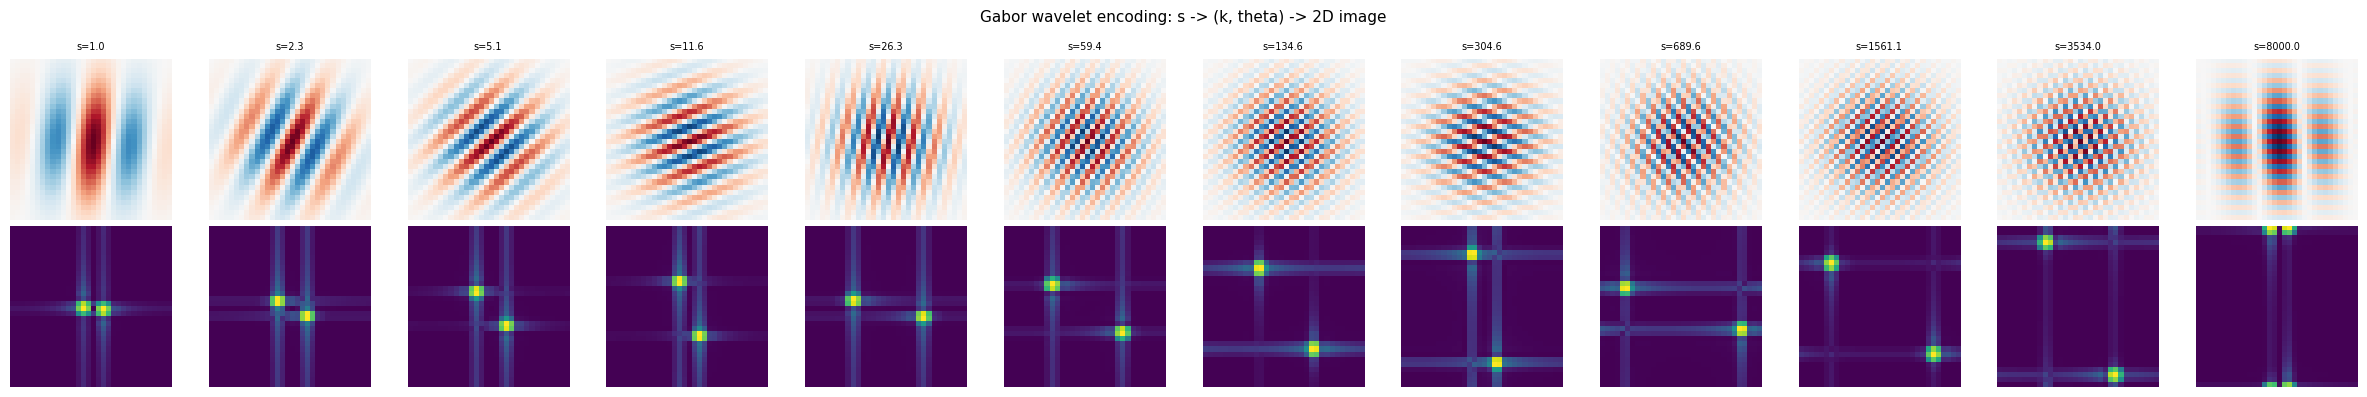

    s_orig   k_enc   k_dec    k_err%   th_enc   th_dec     th_err       s_dec    s_err%
---------------------------------------------------------------------------------------
      1.00   2.000   1.997   -0.161%     6.00     5.74    -0.259 deg        1.00   +0.000%
      2.26   3.273   3.277   +0.122%    27.27    27.20    -0.069 deg        2.26   -0.057%
      5.12   4.545   4.540   -0.111%    48.55    48.50    -0.046 deg        5.12   -0.038%
     11.60   5.818   5.815   -0.057%    69.82    69.81    -0.007 deg       11.60   -0.005%
     26.26   7.091   7.098   +0.099%    13.09    13.13    +0.044 deg       26.27   +0.036%
     59.45   8.364   8.374   +0.123%    34.36    34.40    +0.035 deg       59.46   +0.028%
    134.57   9.636   9.636   -0.002%    55.64    55.67    +0.032 deg      134.61   +0.026%
    304.64  10.909  10.916   +0.065%    76.91    76.93    +0.025 deg      304.70   +0.020%
    689.62  12.182  12.174   -0.066%    20.18    20.15    -0.035 deg      689.42   -0.029%
   15

In [20]:
# === Test: 12 log-spaced s values from 1 to 8000 ===
s_values = np.logspace(np.log10(1.0), np.log10(8000.0), 12)

# Encode all: generate Gabor wavelets and record encoded k, theta
gabor_images = []
k_enc_list = []
theta_enc_list = []

for s in s_values:
    img, k_enc, theta_enc = embed_eigenfrequency_wavelet(s)
    gabor_images.append(img)
    k_enc_list.append(k_enc)
    theta_enc_list.append(theta_enc)

# --- Plot spatial images (row 1) and FFT images (row 2) ---
fig, axes = plt.subplots(2, 12, figsize=(24, 4))
for i in range(12):
    axes[0, i].imshow(gabor_images[i], cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"s={s_values[i]:.1f}", fontsize=7)

    F_mag = np.abs(np.fft.fftshift(np.fft.fft2(
        gabor_images[i] - np.mean(gabor_images[i]))))
    axes[1, i].imshow(np.log1p(F_mag), cmap="viridis")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Spatial", fontsize=9)
axes[1, 0].set_ylabel("FFT", fontsize=9)
plt.suptitle("Gabor wavelet encoding: s -> (k, theta) -> 2D image", fontsize=11)
plt.tight_layout()
plt.show()

# --- Decode and print error table ---
header = (f"{'s_orig':>10s}  {'k_enc':>6s}  {'k_dec':>6s}  {'k_err%':>8s}  "
          f"{'th_enc':>7s}  {'th_dec':>7s}  {'th_err':>9s}  "
          f"{'s_dec':>10s}  {'s_err%':>8s}")
print(header)
print("-" * len(header))

for i, s in enumerate(s_values):
    s_dec, k_dec, theta_dec = extract_eigenfrequency_from_wavelet(gabor_images[i])
    k_enc = k_enc_list[i]
    th_enc_deg = np.degrees(theta_enc_list[i])
    th_dec_deg = np.degrees(theta_dec)

    k_err = (k_dec - k_enc) / k_enc * 100
    th_diff = theta_dec - theta_enc_list[i]
    th_diff = (th_diff + np.pi/2) % np.pi - np.pi/2
    th_err_deg = np.degrees(th_diff)
    s_err = (s_dec - s) / s * 100

    print(f"{s:10.2f}  {k_enc:6.3f}  {k_dec:6.3f}  {k_err:+7.3f}%  "
          f"{th_enc_deg:7.2f}  {th_dec_deg:7.2f}  {th_err_deg:+8.3f} deg  "
          f"{s_dec:10.2f}  {s_err:+7.3f}%")

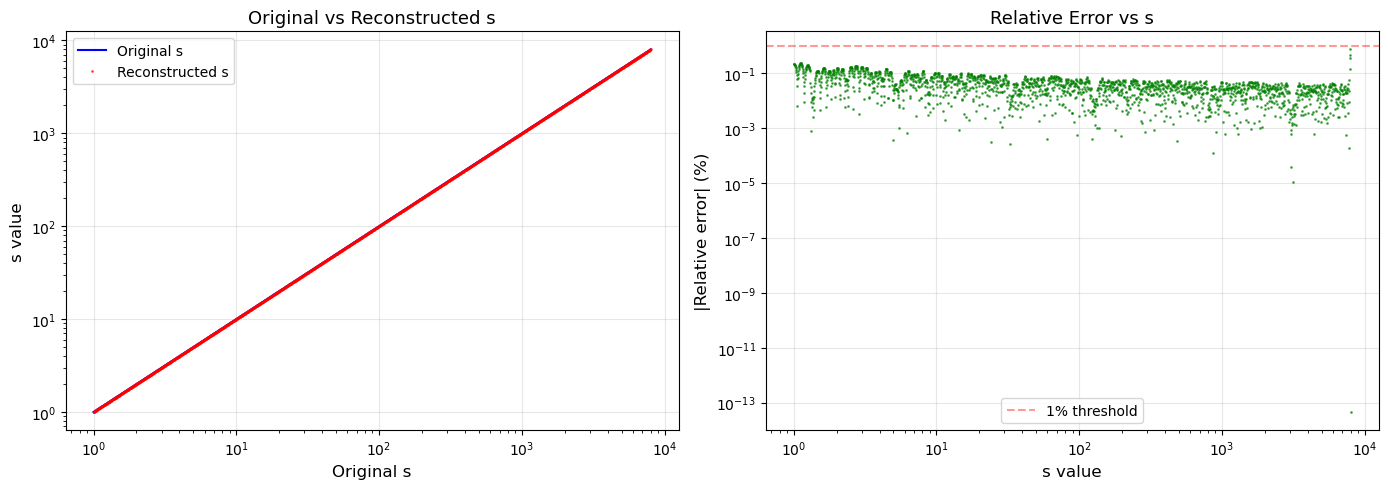

Reconstruction error over 2000 log-spaced s values [1, 8000]:
  Mean |error|:   0.0446 %
  Median |error|: 0.0328 %
  Max |error|:    0.7463 %
  Std |error|:    0.0449 %
  Fraction < 1%:  100.0 %


In [21]:
# === Dense encode-decode test: original vs reconstructed s ===
n_test = 2000
s_original = np.logspace(np.log10(1.0), np.log10(8000.0), n_test)
s_reconstructed = np.zeros(n_test)

for i, s in enumerate(s_original):
    img, _, _ = embed_eigenfrequency_wavelet(s)
    s_rec, _, _ = extract_eigenfrequency_from_wavelet(img)
    s_reconstructed[i] = s_rec

rel_error = (s_reconstructed - s_original) / s_original * 100  # signed %

# --- Two-panel plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: original vs reconstructed
ax1.plot(s_original, s_original, 'b-', linewidth=1.5, label='Original s')
ax1.plot(s_original, s_reconstructed, 'r.', markersize=2, alpha=0.6, label='Reconstructed s')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Original s', fontsize=12)
ax1.set_ylabel('s value', fontsize=12)
ax1.set_title('Original vs Reconstructed s', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: relative error
ax2.plot(s_original, np.abs(rel_error), 'g.', markersize=2, alpha=0.6)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('s value', fontsize=12)
ax2.set_ylabel('|Relative error| (%)', fontsize=12)
ax2.set_title('Relative Error vs s', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.4, label='1% threshold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics
abs_err = np.abs(rel_error)
print(f"Reconstruction error over {n_test} log-spaced s values [1, 8000]:")
print(f"  Mean |error|:   {np.mean(abs_err):.4f} %")
print(f"  Median |error|: {np.median(abs_err):.4f} %")
print(f"  Max |error|:    {np.max(abs_err):.4f} %")
print(f"  Std |error|:    {np.std(abs_err):.4f} %")
print(f"  Fraction < 1%:  {np.mean(abs_err < 1.0)*100:.1f} %")